### Retail Sales EDA :  To explore retail sales data nad identify   
- Sales trends
- Product performance
- Customer behavior
- Revenue patterns
- Business opportunities


### import libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


### Load cleaned Dataset


In [2]:
df = pd.read_csv(
    "../Dataset/Cleaned_Retail_Sales_Dataset.csv"
)
df.head()

,Transaction_ID,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Purchase_Date,Customer_City,Payment_Method,Customer_Age,Customer_Gender
0,T0001,C0126,Sports,Football,1,25000,25000,2025-05-21,Karachi,Credit Card,65.0,Male
1,T0002,C0048,Sports,Football,7,500,3500,2025-01-16,Karachi,Credit Card,50.0,Male
2,T0003,C0302,Beauty,Skin Care,7,1000,7000,2025-08-18,Lahore,Cash,28.0,Female
3,T0004,C0053,Grocery,Snacks,3,1000,3000,2025-06-22,Lahore,Online Payment,24.0,Female
4,T0005,C0275,Grocery,Snacks,1,25000,25000,2025-08-24,Islamabad,Online Payment,23.0,Female


In [4]:
df.shape

(1188, 12)

In [6]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Product_Category', 'Product_Name',
       'Quantity', 'Unit_Price', 'Total_Amount', 'Purchase_Date',
       'Customer_City', 'Payment_Method', 'Customer_Age', 'Customer_Gender'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188 entries, 0 to 1187
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1188 non-null   object 
 1   Customer_ID       1188 non-null   object 
 2   Product_Category  1188 non-null   object 
 3   Product_Name      1188 non-null   object 
 4   Quantity          1188 non-null   int64  
 5   Unit_Price        1188 non-null   int64  
 6   Total_Amount      1188 non-null   int64  
 7   Purchase_Date     1188 non-null   object 
 8   Customer_City     1188 non-null   object 
 9   Payment_Method    1188 non-null   object 
 10  Customer_Age      1188 non-null   float64
 11  Customer_Gender   1188 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 111.5+ KB


### convert Date Column

In [8]:
df["Purchase_Date"] = pd.to_datetime(
    df["Purchase_Date"]
)

### Create Additional columns

In [9]:
# create month volumn
df["Month"] = df["Purchase_Date"].dt.month_name()

In [10]:
# create month number
df["Month_Number"] = df["Purchase_Date"].dt.month

In [11]:
# create year column
df["Year"] = df["Purchase_Date"].dt.year

### check the changes

In [12]:
df[["Purchase_Date", "Month", "Month_Number", "Year"]].head()

,Purchase_Date,Month,Month_Number,Year
0,2025-05-21,May,5,2025
1,2025-01-16,January,1,2025
2,2025-08-18,August,8,2025
3,2025-06-22,June,6,2025
4,2025-08-24,August,8,2025


## Check Business KPIS(Overall numbers)

In [13]:
# Calculate Total Revenue (Sum of all order amounts)
total_revenue = df["Total_Amount"].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 73085000


In [14]:
# Calculate Total Orders (Count of unique transaction IDs)
total_orders = df["Transaction_ID"].count()
print(f"Total Orders: {total_orders}")

Total Orders: 1188


In [15]:
# Calculate Average Order Value (AOV)
average_order_value = total_revenue / total_orders
print(f"Average Order Value (AOV): {average_order_value}")

Average Order Value (AOV): 61519.360269360266


### Check Mothy Sales Trends

In [16]:
monthly_sales = df.groupby(["Month_Number", "Month"])["Total_Amount"].sum().reset_index()
monthly_sales = monthly_sales.sort_values("Month_Number")

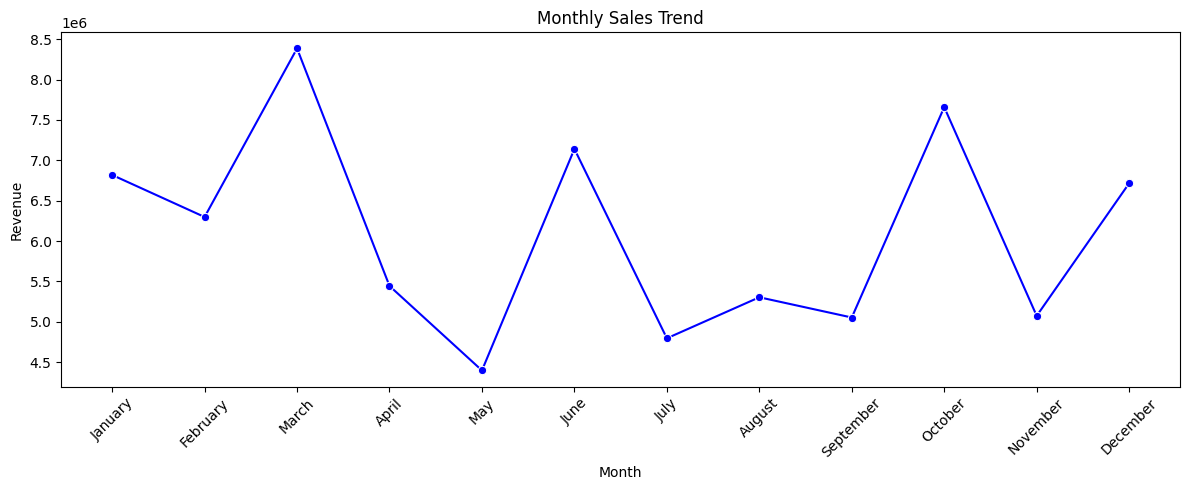

In [17]:
# Plot Monthly Sales Trend Line Chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Month", y="Total_Amount", marker="o", color="blue")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### OBSERVATIONS:  
Sales fluctuate throughout the year.   
Peak months represent high customer purchasing activity.

### Check Top Selling Products by Quantity

In [18]:
top_products = df.groupby("Product_Name")["Quantity"].sum().sort_values(ascending=False).head(10)

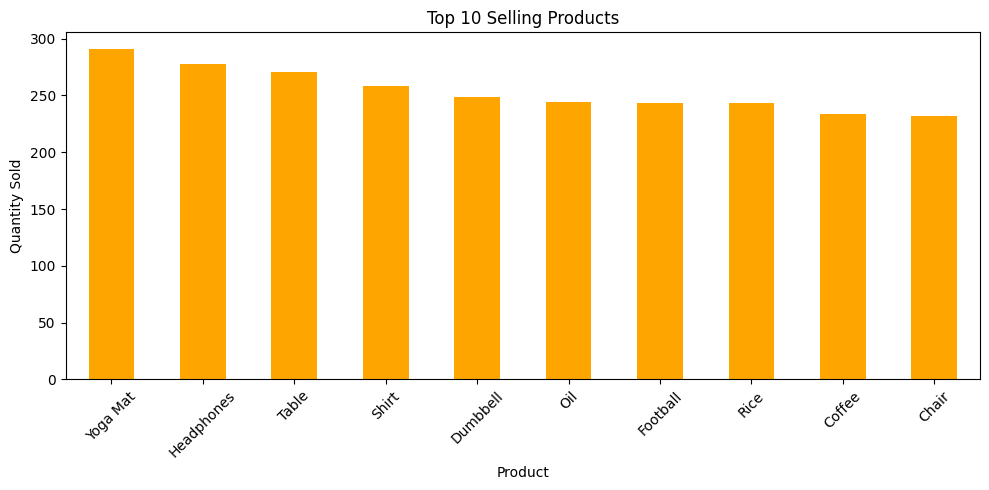

In [19]:
# Plot Top Products Bar Chart
plt.figure(figsize=(10, 5))
top_products.plot(kind="bar", color="orange")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check Revenue generated by each product category

In [21]:
category_sales = df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=False)

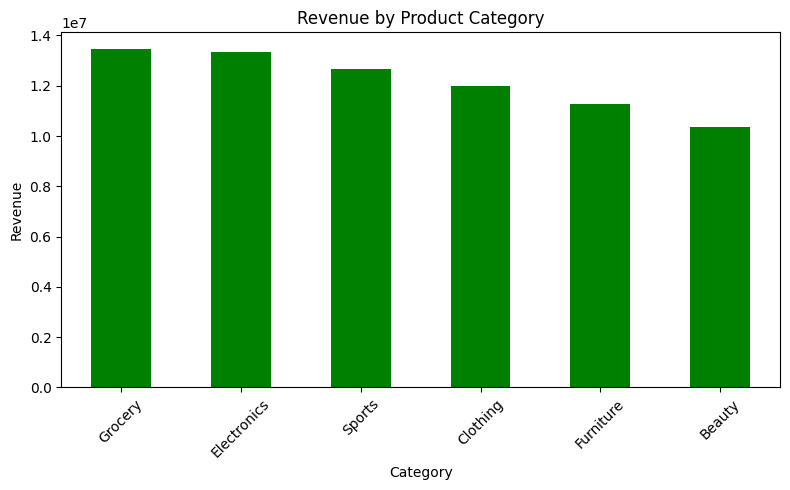

In [22]:
# Plot Category Revenue Bar Chart
plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar", color="green")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check which city contributes most Revenue

In [23]:
city_revenue = df.groupby("Customer_City")["Total_Amount"].sum().sort_values(ascending=False)

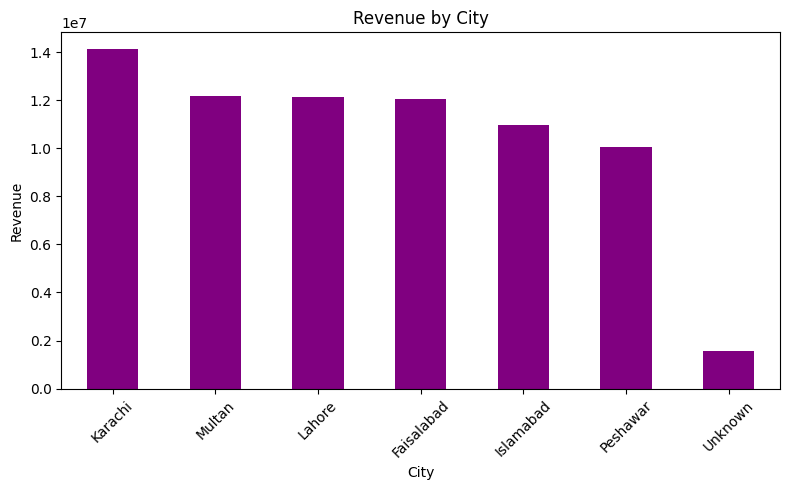

In [24]:
plt.figure(figsize=(8, 5))
city_revenue.plot(kind="bar", color="purple")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### check customer purchasing pattern

In [ ]:
# customer spending analysis
customer_spending = df.groupby("Customer_ID")["Total_Amount"].sum().sort_values(ascending=False)
print("Top 10 Spending Customers:\n", customer_spending.head(10), "\n")

Top 10 Spending Customers:
 Customer_ID
C0493    878000
C0338    876000
C0421    760000
C0383    748000
C0151    740000
C0009    681000
C0154    661000
C0196    650000
C0325    635000
C0134    626000
Name: Total_Amount, dtype: int64 



In [26]:
# Gender Analysis
gender_sales = df.groupby("Customer_Gender")["Total_Amount"].sum()

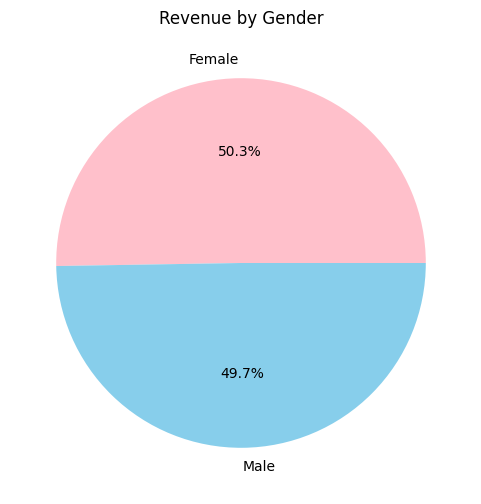

In [27]:
plt.figure(figsize=(6, 6))
gender_sales.plot(kind="pie", autopct="%1.1f%%", colors=["pink", "skyblue"])
plt.title("Revenue by Gender")
plt.ylabel("")
plt.show()

### check payment method distribution

In [28]:
payment_distribution = df["Payment_Method"].value_counts()

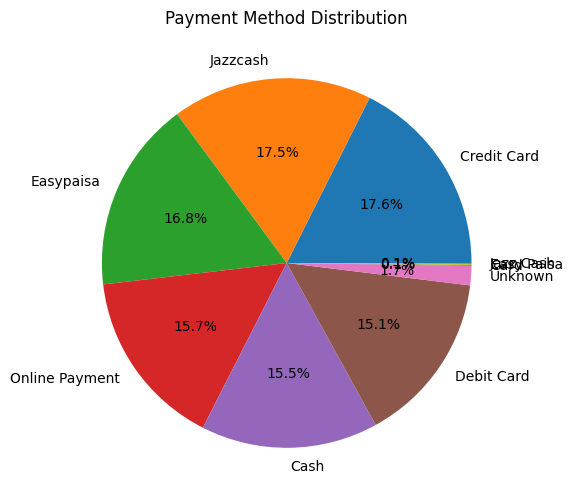

In [29]:
plt.figure(figsize=(6, 6))
payment_distribution.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

### check peak sales period

In [30]:
daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()
print("Top 10 Peak Sales Days:\n", daily_sales.sort_values(ascending=False).head(10))

Top 10 Peak Sales Days:
 Purchase_Date
2025-06-07    1245000
2025-03-10    1087500
2025-10-02     999500
2025-03-16     985000
2025-06-04     870000
2025-07-13     780000
2025-11-17     775500
2025-08-23     775000
2025-10-13     751000
2025-10-24     750000
Name: Total_Amount, dtype: int64


### SAVE EDA RESULTS

In [31]:
# Save the Monthly Sales trend summary inside the output folder
monthly_sales.to_csv("output/monthly_sales.csv", index=False)

In [32]:
# Save the Product Category revenue summary
category_sales.to_csv("output/category_sales.csv", index=True)

In [33]:
# save the Customer City revenue summary
city_revenue.to_csv("output/city_revenue.csv", index=True)

In [34]:
print("Success! All 3 CSV files have been saved inside the output folder.")

Success! All 3 CSV files have been saved inside the output folder.
